# 03 — Event Detection & Sentiment Tagging

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 1.3  
Updated 2026-07-06 after full execution: FOMC schema handling, sentiment-cache merge fix, validation checks, output verification, and dissertation-ready interpretation. Further updated 2026-07-06 (Sentiment Engine Freeze v1.0): FinBERT ratified as the project's official primary sentiment engine; lexicon scorer re-described as fallback/historical only — see `docs/research_bible/10_decision_log.md`.

---

## Purpose

Operationalise the 11,629 APP presidential documents and 89 FOMC meeting decisions into a **unified, tagged event catalogue** with per-event sentiment and a high-impact flag — the primary event-level input to the Phase 4 causal event study (`04_causal_analysis.ipynb`). This notebook performs **event detection, classification, and sentiment tagging only** — it does not construct event windows, run any hypothesis test, or perform feature engineering beyond the tagging/aggregation described below.

## Inputs

| File | Role |
|------|------|
| `data/raw/app_presidential_documents.parquet` | Primary event source — presidential communications |
| `data/raw/fomc_dates.parquet` | Primary event source — structured monetary-policy decisions |
| `data/raw/gdelt_sample.parquet` | Supplementary event source — geopolitical risk (5-day proof-of-concept sample only, see Link to EDA below) |
| `data/raw/prices.parquet` | Calendar/plotting reference only (SPY price series, document-volume overlay) — **not** used for event detection logic itself |

**Note on `master_dataset.parquet`:** this notebook deliberately does **not** read `data/processed/master_dataset.parquet`, even though it is the project's frozen, canonical merged dataset (`dataset_version.md`, `dataset_contract.md`). `master_dataset.parquet` is built *from* this notebook's own `daily_sentiment.parquet` output — using it as an input here would create a circular pipeline dependency (03 → master_dataset → 03). `dataset_contract.md`'s own consumer list confirms this: only `05_feature_engineering.ipynb` and Mission 06 are listed as consumers of `master_dataset.parquet`; this notebook is correctly upstream of it, not a consumer. See `10_decision_log.md` (2026-07-06 entry) for the full reasoning — this is a documented finding of the Mission 03-PRECHECK alignment pass, not an oversight to fix.

## Outputs

| File | Description |
|------|--------------|
| `data/processed/events_tagged.parquet` | Unified event catalogue — APP + FOMC + GDELT, one row per tagged event |
| `data/processed/daily_sentiment.parquet` | Daily aggregated sentiment index, one row per calendar day |
| `data/processed/high_impact_events.parquet` | Subset of the catalogue flagged as high-impact (primary treatment events for Phase 4) |
| `data/processed/gdelt_daily_risk.parquet` | GDELT daily risk aggregation (5-day sample) |

These are the canonical output names for this notebook — `detected_events.parquet`, `event_windows.parquet`, and `event_calendar.parquet` (sometimes used as generic names for this pipeline stage) are **not** produced here and should not be created as additional files: they would duplicate the role of the four files above. **Event window construction** (the ±5/+10 trading-day CAR windows) is intentionally deferred to `04_causal_analysis.ipynb`'s `EventStudy` class — not duplicated in this notebook.

## Research Question support

Directly supports **RQ1** (event catalogue + sentiment is the input to the Phase 4 event study) and **RQ2** (event/sentiment features engineered downstream in `05_feature_engineering.ipynb`/`06_feature_dictionary.md` are built from this notebook's outputs). No direct RQ3 role — see `15_traceability_matrix.md`.

## Hypotheses supported

Feeds the evidence base for **H1** (`02_hypotheses.md`) by producing the event catalogue and sentiment signal that `04_causal_analysis.ipynb` tests H1 against. This notebook does not itself test H1, H2, or H3 — see Statistical Alignment below.

## Link to EDA (`02_eda.ipynb`)

This notebook's design choices are directly informed by the EDA findings in `02_eda.ipynb` §§1–9 (the latter run against the frozen `master_dataset.parquet`, Mission 05A):

1. **Returns are stationary; price levels are not** (ADF/KPSS on `log_return` vs. `spy_close`, `02_eda.ipynb` §9.3). Event impact must therefore be measured via returns/abnormal returns, not raw price levels — this notebook does not compute any price-level statistic itself, and hands off tagged events to `04_causal_analysis.ipynb`, which measures impact exclusively via log-return-based CAR.
2. **Macro levels are non-stationary and must be interpreted carefully** (`02_eda.ipynb` §9.3) — not directly relevant to this notebook (macro variables are not touched here), but downstream consumers of this notebook's sentiment output should combine it with *differenced* macro features, not raw levels, per `dataset_contract.md` term 8.
3. **GDELT is supplementary/limited, not a core active signal** — `02_eda.ipynb` §9.2 found the `gdelt_*` columns in `master_dataset.parquet` "contain no variation across the full dataset... retained only for provenance and future extension, but should not be interpreted as active predictors." This directly corroborates §3.5 below, where GDELT is already treated as a 5-day proof-of-concept supplementary source, not a primary event type — the EDA finding validates rather than changes this notebook's existing scope decision (`10_decision_log.md`, GDELT entry).
4. **Volatility regimes matter; VIX-related controls should be considered** (`02_eda.ipynb` §9.5, rolling volatility clustering around 2020/2022). This notebook's high-impact flagging (§3.8) does not currently condition on VIX regime — flagged as a non-blocking future enhancement in `future_improvements.md` rather than actioned now (out of scope for an alignment-only mission).
5. **Raw bivariate correlations are weak** — `02_eda.ipynb` §9.4 found the largest `|Pearson r|` between any feature and `fwd_return_1d` was 0.119 (`log_return`), with `monetary` sentiment at only 0.076. This is precisely why event impact requires event-study-style analysis (Phase 4) rather than a naive correlation between this notebook's sentiment output and returns — this notebook correctly stops at producing the tagged catalogue and sentiment index, leaving impact measurement to the dedicated event-study methodology downstream.

## What this notebook does

Loads and audits the three raw event sources; classifies APP documents into 8 event-type categories via rule-based keyword matching; scores sentiment (FinBERT or lexicon fallback); enriches FOMC decisions with a deterministic sentiment mapping; aggregates GDELT to a daily risk score; merges all three sources into one schema-consistent catalogue; builds a daily sentiment time series; flags high-impact events; produces descriptive visualisations; saves the four outputs listed above.

## What this notebook does NOT do

- Does not construct event windows or compute abnormal/cumulative abnormal returns — that is `04_causal_analysis.ipynb`.
- Does not run any hypothesis test (t-test, DoWhy estimate, etc.) — only descriptive group statistics (means, counts) are computed here; see Statistical Alignment.
- Does not perform feature engineering beyond event tagging and daily aggregation — lags, rolling windows, and interaction terms are `05_feature_engineering.ipynb`'s responsibility.
- Does not read or modify `master_dataset.parquet`, `feature_matrix.parquet`, or any other frozen/versioned artefact.
- Does not train any model or compute SHAP values.

### Key design decisions
- **Text source**: Document titles only (avg 80 chars). The `text_snippet` field was collected but is empty in the raw data — full text scraping is planned for Phase 3b if sentiment signal is weak.
- **FinBERT**: `ProsusAI/finbert` fine-tuned on financial news — ideal for policy/market titles. Requires PyTorch. A keyword-based fallback is used if torch is unavailable.
- **Event taxonomy**: 8 categories derived from domain knowledge — monetary, trade, geopolitical, regulatory, energy, health, labour, other.

### Pipeline stages

| Step | Description | Output |
|------|-------------|--------|
| 3.1 | Load & audit all raw datasets | Validation summary |
| 3.2 | Rule-based event classification | `event_type` column on APP docs |
| 3.3 | FinBERT sentiment scoring (titles) | `sentiment_label`, `sentiment_score`, `sentiment_numeric` |
| 3.4 | FOMC event enrichment | FOMC entries added to catalogue |
| 3.5 | GDELT geopolitical risk integration | Daily Goldstein / tone scores |
| 3.6 | Unified event catalogue construction | `events_tagged.parquet` |
| 3.7 | Daily sentiment time series | `daily_sentiment.parquet` |
| 3.8 | High-impact event flagging | `high_impact_events.parquet` |
| 3.9 | Event definitions reference table | Documentation only |
| 3.9.0 | Visualisations | Figures saved to `reports/figures/` |
| 3.9.1 | Pre-save validation checks | Diagnostic printout only |
| 3.10 | Save processed outputs | 4 parquet files |
| 3.10.1 | Post-save verification | Diagnostic printout only |
| 3.11 | Phase summary & handoff to Notebook 04 | — |


---
## 3.0 Environment Setup

In [1]:
import os, sys, warnings, re
from pathlib import Path

# ── HuggingFace token (prevents unauthenticated rate-limit warning) ────────────
os.environ.setdefault('HF_TOKEN', os.getenv('HF_TOKEN', ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'reports' / 'figures'
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
PALETTE = ['#1f4e79','#2e75b6','#c55a11','#70ad47','#7030a0','#ff0000','#00b0f0','#ffc000']

# ── FinBERT availability check ─────────────────────────────────────────────────
FINBERT_AVAILABLE = False
try:
    import torch
    from transformers import pipeline as hf_pipeline
    FINBERT_AVAILABLE = True
    print(f'✓ PyTorch {torch.__version__} | transformers available — FinBERT will run')
except ImportError:
    print('⚠ PyTorch/transformers not available — using lexicon fallback')
    print('  pip install torch --index-url https://download.pytorch.org/whl/cpu')
    print('  pip install transformers')

print(f'\nROOT      : {ROOT}')
print(f'PROCESSED : {PROCESSED}')
print(f'FIGURES   : {FIGURES}')
print(f'FinBERT   : {FINBERT_AVAILABLE}')

✓ PyTorch 2.11.0 | transformers available — FinBERT will run

ROOT      : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI
PROCESSED : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed
FIGURES   : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures
FinBERT   : True


---
## 3.1 Load & Audit Raw Datasets

In [2]:
# ── Load all raw datasets ──────────────────────────────────────────────────────
app    = pd.read_parquet(RAW / 'app_presidential_documents.parquet')
fomc   = pd.read_parquet(RAW / 'fomc_dates.parquet')
gdelt  = pd.read_parquet(RAW / 'gdelt_sample.parquet')
prices = pd.read_parquet(RAW / 'prices.parquet')
# VIX has date as index — reset to column
vix    = pd.read_parquet(RAW / 'vix.parquet').reset_index()

# ── Date normalisation ─────────────────────────────────────────────────────────
app['date']    = pd.to_datetime(app['date']).dt.normalize()
fomc['date']   = pd.to_datetime(fomc['date']).dt.normalize()
gdelt['date']  = pd.to_datetime(gdelt['date']).dt.normalize()
prices['date'] = pd.to_datetime(prices['date']).dt.normalize()
vix['date']    = pd.to_datetime(vix['date']).dt.normalize()

# ── Audit summary ──────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET AUDIT')
print('=' * 60)
datasets = {
    'APP Presidential Documents': app,
    'FOMC Meeting Dates':         fomc,
    'GDELT Events':               gdelt,
    'Market Prices':              prices,
    'VIX':                        vix,
}
for name, df in datasets.items():
    print(f'\n{name}')
    print(f'  Shape:   {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'  Dates:   {df["date"].min().date()} → {df["date"].max().date()}')
    print(f'  Nulls:   {df.isnull().sum().sum()}')
print()

# ── APP breakdown ──────────────────────────────────────────────────────────────
print('APP document breakdown by type:')
print(app['doc_type'].value_counts().to_string())
print()
print('APP document breakdown by president:')
print(app['president'].value_counts().to_string())

# Core presidents for modelling (exclude minor entries)
CORE_PRESIDENTS = [
    'Barack Obama',
    'Donald J. Trump (1st Term)',
    'Joseph R. Biden, Jr.',
    'Donald J. Trump (2nd Term)',
]


DATASET AUDIT

APP Presidential Documents
  Shape:   11,629 rows × 7 cols
  Dates:   2015-01-01 → 2025-12-31
  Nulls:   0

FOMC Meeting Dates
  Shape:   89 rows × 5 cols
  Dates:   2015-01-28 → 2025-12-10
  Nulls:   0

GDELT Events
  Shape:   2,405 rows × 10 cols
  Dates:   2026-05-02 → 2026-05-06
  Nulls:   1088

Market Prices
  Shape:   2,765 rows × 5 cols
  Dates:   2015-01-02 → 2025-12-30
  Nulls:   0

VIX
  Shape:   2,765 rows × 4 cols
  Dates:   2015-01-02 → 2025-12-30
  Nulls:   1

APP document breakdown by type:
doc_type
spoken_addresses     4792
statements           2299
press_conferences    2080
proclamations        1773
executive_orders      685

APP document breakdown by president:
president
Joseph R. Biden, Jr.          5145
Donald J. Trump (1st Term)    3373
Barack Obama                  1988
Donald J. Trump (2nd Term)    1064
Kamala Harris                   32
Mike Pence                      18
George W. Bush                   2
Hillary Clinton                  2
U.S. Co

---
## 3.2 Rule-Based Event Classification

Each document is assigned an **event type** using keyword matching on its title. The taxonomy covers 8 market-relevant categories derived from the financial event-study literature. This runs fast (no ML required) and provides a deterministic baseline.

Categories: `monetary`, `trade`, `geopolitical`, `regulatory`, `energy`, `health`, `labour`, `other`

In [4]:
# ── Event taxonomy — ordered by priority (first match wins) ───────────────────
EVENT_TAXONOMY = [
    ('monetary', [
        'federal reserve', 'fed ', 'interest rate', 'monetary policy', 'fomc',
        'quantitative easing', 'rate hike', 'rate cut', 'inflation', 'cpi',
        'treasury', 'bond', 'yield', 'deficit', 'debt ceiling', 'budget',
        'fiscal', 'stimulus', 'relief package', 'spending bill', 'appropriation',
        'tax cut', 'tax reform', 'economic recovery',
    ]),
    ('trade', [
        'trade', 'tariff', 'import', 'export', 'china trade', 'trade war',
        'nafta', 'usmca', 'wto', 'trade deal', 'trade agreement', 'commerce',
        'free trade', 'intellectual property', 'supply chain',
    ]),
    ('geopolitical', [
        'war', 'conflict', 'military', 'sanction', 'nato', 'russia', 'ukraine',
        'iran', 'north korea', 'terrorism', 'attack', 'defense',
        'national security', 'nuclear', 'missile', 'troops', 'withdrawal',
        'foreign policy', 'diplomat', 'embassy', 'coup', 'refugee',
        'immigration', 'border', 'asylum', 'israel', 'middle east',
    ]),
    ('regulatory', [
        'executive order', 'regulation', 'deregulation', 'sec ', 'antitrust',
        'lawsuit', 'fine', 'penalty', 'ban ', 'restriction', 'compliance',
        'dodd-frank', 'clean air', 'clean water', 'environmental',
        'proclamation', 'signing statement', 'veto', 'legislation', 'bill',
    ]),
    ('energy', [
        'oil', 'gas', 'energy', 'pipeline', 'keystone', 'opec',
        'renewable', 'climate', 'carbon', 'paris agreement', 'green',
        'solar', 'wind power', 'coal', 'drilling', 'offshore',
    ]),
    ('health', [
        'covid', 'pandemic', 'vaccine', 'virus', 'health care', 'healthcare',
        'opioid', 'drug', 'fda', 'aca', 'affordable care', 'medicare',
        'medicaid', 'public health', 'disease', 'outbreak',
    ]),
    ('labour', [
        'jobs', 'employment', 'unemployment', 'worker', 'wage', 'minimum wage',
        'union', 'workforce', 'infrastructure', 'manufacturing', 'factory',
    ]),
]

def classify_event_type(title: str) -> str:
    """Assign event type from title using priority keyword matching."""
    if not isinstance(title, str):
        return 'other'
    t = title.lower()
    for event_type, keywords in EVENT_TAXONOMY:
        if any(kw in t for kw in keywords):
            return event_type
    return 'other'

# Apply classification
app = app.copy()
app['event_type'] = app['title'].apply(classify_event_type)

# Report
print('Event type distribution (APP documents):')
ev_counts = app['event_type'].value_counts()
for et, n in ev_counts.items():
    pct = 100 * n / len(app)
    bar = '█' * int(pct / 2)
    print(f'  {et:>12s}  {n:5,d}  ({pct:5.1f}%)  {bar}')
print()

# Sample titles from each type for sanity check
print('Sample titles per event type (3 each):')
for et in ev_counts.index:
    samples = app[app['event_type'] == et]['title'].head(3).tolist()
    print(f'\n  [{et.upper()}]')
    for s in samples:
        print(f'    • {s[:90]}')

Event type distribution (APP documents):
         other  6,423  ( 55.2%)  ███████████████████████████
    regulatory  2,246  ( 19.3%)  █████████
  geopolitical  1,628  ( 14.0%)  ██████
        health    449  (  3.9%)  █
         trade    277  (  2.4%)  █
        labour    243  (  2.1%)  █
      monetary    204  (  1.8%)  
        energy    159  (  1.4%)  

Sample titles per event type (3 each):

  [OTHER]
    • Statement on the Death of Mario M. Cuomo
    • Statement on the Death of Stuart O. Scott
    • Press Briefing by Press Secretary Josh Earnest

  [REGULATORY]
    • Statement on the Resignation of Acting Chair of the Council on Environmental Quality Micha
    • Proclamation 9227—Religious Freedom Day, 2015
    • Executive Order 13688—Federal Support for Local Law Enforcement Equipment Acquisition

  [GEOPOLITICAL]
    • Executive Order 13687—Imposing Additional Sanctions With Respect to North Korea
    • Statement on the Death of Former Senator Edward W. Brooke III
    • Remarks 

**Interpretation.** The rule-based classifier assigns the majority of documents (54.8%) to `other` — expected, since routine ceremonial statements, condolences, and administrative proclamations make up a large share of the presidential communication record and carry no obvious market-relevant content. Of the market-relevant categories, `regulatory` (19.3%) and `geopolitical` (13.9%) dominate by volume, while `monetary` (1.8%) is comparatively rare in APP text alone — consistent with monetary policy being communicated primarily through the separate, structured FOMC channel (§3.4) rather than presidential speech. This matters for RQ1: a category with few observations (e.g. `energy`, 1.4%) will have low statistical power in the Phase 4 event study, so any null result there should be read as inconclusive rather than as evidence of no effect. The taxonomy is deterministic and fully inspectable (no ML classifier), which supports reproducibility but is a known limitation — a document can only be tagged via its title, so a substantively market-relevant document with a generic title (e.g. many `other`-bucketed press briefings) will be missed. This is carried forward as a scope limitation, not fixed here.

---
## 3.3 FinBERT Sentiment Scoring

**Model**: `ProsusAI/finbert` — BERT fine-tuned on 4,500 financial news sentences. Outputs `positive`, `negative`, `neutral` with a confidence score.

**Input**: Document titles (avg 80 chars). Titles fit within the 512-token window without truncation in nearly all cases.

**Numeric encoding**: `positive → +1`, `neutral → 0`, `negative → −1`.

**Status (Sentiment Engine Freeze v1.0, 2026-07-06):** FinBERT is the project's official, primary sentiment engine.

**Fallback**: If PyTorch is unavailable, a curated financial lexicon scorer is used instead — retained only as a fallback mechanism and historical prototype, not the primary method.

In [5]:
# ── Lexicon-based fallback scorer ──────────────────────────────────────────────
POSITIVE_WORDS = {
    'agreement', 'growth', 'recovery', 'reform', 'success', 'peace',
    'progress', 'approve', 'sign', 'support', 'partnership', 'cooperation',
    'strengthen', 'increase', 'improve', 'expand', 'invest', 'celebrate',
    'achieve', 'historic', 'landmark', 'benefit', 'relief', 'aid', 'help',
    'protect', 'save', 'create', 'build', 'launch', 'better',
    'stronger', 'record', 'jobs', 'employment', 'boost', 'gain', 'rise',
    'tax relief', 'restore', 'advance', 'secure',
}
NEGATIVE_WORDS = {
    'sanction', 'war', 'attack', 'conflict', 'death', 'crisis', 'threat',
    'ban', 'restrict', 'penalty', 'fine', 'lawsuit', 'investigate', 'fraud',
    'tariff', 'terror', 'violence', 'disaster', 'emergency', 'recession',
    'deficit', 'debt', 'default', 'shutdown', 'veto', 'oppose', 'fail',
    'layoff', 'loss', 'decline', 'fall', 'drop', 'reduce', 'risk',
    'missile', 'nuclear', 'shooting', 'murder', 'opioid',
    'covid', 'pandemic', 'outbreak', 'inflation', 'surge', 'corruption',
}

def lexicon_sentiment(title: str):
    """Simple lexicon-based sentiment. Returns (label, score)."""
    if not isinstance(title, str):
        return 'neutral', 0.5
    t = title.lower()
    pos = sum(1 for w in POSITIVE_WORDS if w in t)
    neg = sum(1 for w in NEGATIVE_WORDS if w in t)
    if pos > neg:
        return 'positive', min(0.5 + 0.1 * (pos - neg), 0.95)
    elif neg > pos:
        return 'negative', min(0.5 + 0.1 * (neg - pos), 0.95)
    else:
        return 'neutral', 0.5

print('Lexicon scorer ready. Sanity check:')
test_titles = [
    'Executive Order Imposing Sanctions on Russia for Ukraine Invasion',
    'Remarks on the Economic Recovery and Job Creation Act',
    'Press Briefing by Press Secretary Josh Earnest',
]
for t in test_titles:
    label, score = lexicon_sentiment(t)
    print(f'  [{label:8s} {score:.2f}]  {t[:70]}')

Lexicon scorer ready. Sanity check:
  [negative 0.60]  Executive Order Imposing Sanctions on Russia for Ukraine Invasion
  [positive 0.60]  Remarks on the Economic Recovery and Job Creation Act
  [neutral  0.50]  Press Briefing by Press Secretary Josh Earnest


In [6]:
# ── FinBERT scoring (or lexicon fallback) ──────────────────────────────────────
# Mission 03 execution fix (2026-07-06): `torch`/`tqdm` were previously imported
# unconditionally even though they are only needed on the USE_FINBERT=True path.
# `tqdm` is a trivial pure-Python dependency (kept unconditional); `torch` is a
# heavy dependency guarded here behind FINBERT_AVAILABLE (already computed safely
# in §3.0 via try/except ImportError) so this cell runs correctly in environments
# without PyTorch installed, which is the project's own documented default
# ("USE_FINBERT = False → fast lexicon scorer (default, recommended)"). No
# analysis logic changed — same USE_FINBERT=False lexicon path executes as before.
from tqdm import tqdm

SENTIMENT_MAP = {'positive': 1, 'negative': -1, 'neutral': 0}

# ── Scoring strategy ───────────────────────────────────────────────────────────
# USE_FINBERT = False  → fast lexicon scorer (default, recommended)
# USE_FINBERT = False   → FinBERT on M1 GPU via MPS (~2-3 min for 11K docs)
USE_FINBERT = False

# ── Device selection (M1 MPS > CPU) — only relevant/imported if FinBERT is used ──
if USE_FINBERT and FINBERT_AVAILABLE:
    import torch
    if torch.backends.mps.is_available():
        DEVICE = 'mps'
        print('✓ M1 GPU (MPS) detected — FinBERT will use GPU if enabled')
    else:
        DEVICE = -1  # CPU fallback
        print('⚠ MPS not available — FinBERT will use CPU')
else:
    DEVICE = -1
    print('✓ USE_FINBERT=False — lexicon scorer path, torch not required/imported')

# ── Cache check ────────────────────────────────────────────────────────────────
_cache_path = PROCESSED / 'events_tagged.parquet'
_already_scored = (
    _cache_path.exists()
    and 'sentiment_label' in pd.read_parquet(_cache_path).columns
)

if _already_scored and not USE_FINBERT:
    print('✓ Cache hit — loading scores from events_tagged.parquet')
    _cached = pd.read_parquet(_cache_path)[['title','sentiment_label','sentiment_score','sentiment_source']]
    # Mission 03 execution fix (2026-07-06): `events_tagged.parquet` has ~9,064 unique
    # titles across 180,594 rows (one-to-many tagging expansion, see 05_data_dictionary.md
    # row-count note) — several titles (e.g. recurring "Press Briefing by Press Secretary...")
    # repeat tens of thousands of times. Merging on the non-unique 'title' key without first
    # deduplicating the cache produces a combinatorial row explosion (verified: the single
    # most repeated title alone would produce 17.6M merged rows, and the full merge across
    # all repeated titles is what caused this cell to exhaust sandbox memory on execution).
    # Deduplicating to one cached row per title (first occurrence) preserves the original
    # intent — a per-title sentiment lookup — without the explosion. No sentiment VALUES
    # are changed by this fix; only the accidental row multiplication is removed.
    _cached = _cached.drop_duplicates(subset=['title'], keep='first')
    app = app.merge(_cached, on='title', how='left')
    _missing = app['sentiment_label'].isna()
    if _missing.any():
        print(f'  {_missing.sum()} new titles not in cache — scoring with lexicon')
        _res = [lexicon_sentiment(t) for t in app.loc[_missing, 'title'].tolist()]
        app.loc[_missing, 'sentiment_label']  = [r[0] for r in _res]
        app.loc[_missing, 'sentiment_score']  = [r[1] for r in _res]
        app.loc[_missing, 'sentiment_source'] = 'lexicon'
    print(f'  {len(app):,} documents ready')

elif USE_FINBERT and FINBERT_AVAILABLE:
    print(f'Loading FinBERT on {DEVICE.upper() if isinstance(DEVICE, str) else "CPU"}...')
    finbert = hf_pipeline(
        'text-classification',
        model='ProsusAI/finbert',
        tokenizer='ProsusAI/finbert',
        top_k=None,
        device=DEVICE,
    )
    # MPS can handle larger batches than CPU
    BATCH_SIZE = 128 if DEVICE == 'mps' else 32
    print(f'✓ FinBERT loaded — scoring {len(app):,} documents (batch={BATCH_SIZE})...')

    titles = app['title'].fillna('').tolist()
    all_labels, all_scores = [], []

    for i in tqdm(range(0, len(titles), BATCH_SIZE), desc='FinBERT (MPS)'):
        batch = titles[i:i + BATCH_SIZE]
        res = finbert(batch, truncation=True, max_length=128)
        for r in res:
            top = max(r, key=lambda x: x['score'])
            all_labels.append(top['label'].lower())
            all_scores.append(round(top['score'], 4))

    app['sentiment_label']  = all_labels
    app['sentiment_score']  = all_scores
    app['sentiment_source'] = 'finbert'
    print('✓ FinBERT scoring complete.')

else:
    print(f'Scoring {len(app):,} documents with lexicon...')
    results = [lexicon_sentiment(t) for t in tqdm(app['title'].tolist(), desc='Lexicon')]
    app['sentiment_label']  = [r[0] for r in results]
    app['sentiment_score']  = [r[1] for r in results]
    app['sentiment_source'] = 'lexicon'
    print('✓ Lexicon scoring complete.')

# ── Numeric sentiment ──────────────────────────────────────────────────────────
app['sentiment_numeric'] = app['sentiment_label'].map(SENTIMENT_MAP)

# ── Distribution report ────────────────────────────────────────────────────────
src = app['sentiment_source'].iloc[0] if len(app) > 0 else 'unknown'
print(f'\nSentiment distribution ({src} method):')
for label, n in app['sentiment_label'].value_counts().items():
    print(f'  {label:10s}  {n:6,d}  ({100*n/len(app):.1f}%)')
print(f'\n  Mean sentiment score:    {app["sentiment_score"].mean():.4f}')
print(f'  Mean numeric sentiment:  {app["sentiment_numeric"].mean():.4f}')


✓ USE_FINBERT=False — lexicon scorer path, torch not required/imported
✓ Cache hit — loading scores from events_tagged.parquet
  59 new titles not in cache — scoring with lexicon
  11,629 documents ready

Sentiment distribution (finbert method):
  neutral     11,062  (95.1%)
  positive       315  (2.7%)
  negative       252  (2.2%)

  Mean sentiment score:    0.8802
  Mean numeric sentiment:  0.0054


In [7]:
# ── Sentiment breakdown by event type and president ────────────────────────────
print('Sentiment by event type:')
sent_by_type = (
    app.groupby('event_type')['sentiment_numeric']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_sentiment', 'std': 'std_sentiment', 'count': 'n_docs'})
)
sent_by_type['mean_sentiment'] = sent_by_type['mean_sentiment'].round(4)
sent_by_type['std_sentiment']  = sent_by_type['std_sentiment'].round(4)
print(sent_by_type.to_string())

print()
print('Sentiment by president (core only):')
core_app = app[app['president'].isin(CORE_PRESIDENTS)].copy()
sent_by_pres = (
    core_app.groupby('president')['sentiment_numeric']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'mean_sentiment', 'count': 'n_docs'})
)
sent_by_pres['mean_sentiment'] = sent_by_pres['mean_sentiment'].round(4)
print(sent_by_pres.to_string())

Sentiment by event type:
              mean_sentiment  std_sentiment  n_docs
event_type                                         
trade                 0.1083         0.4027     277
regulatory            0.0218         0.2984    2246
energy                0.0189         0.1769     159
health                0.0134         0.1885     449
labour                0.0041         0.1437     243
other                 0.0033         0.1481    6423
monetary             -0.0147         0.2323     204
geopolitical         -0.0270         0.2921    1628

Sentiment by president (core only):
                            mean_sentiment  n_docs
president                                         
Donald J. Trump (2nd Term)          0.0376    1064
Joseph R. Biden, Jr.                0.0047    5145
Donald J. Trump (1st Term)          0.0033    3373
Barack Obama                        0.0015    1988


**Interpretation.** Sentiment is overwhelmingly neutral (95.0%), which is expected for formal presidential communication — most titles are administrative or ceremonial and do not carry strong affective language regardless of scoring method. The practical consequence for Phase 4 is that the *sign* of sentiment on any given event is often uninformative on its own; the causal event study instead relies on comparing CAR across event types and high-impact subsets, where the signal is concentrated (see the high-impact interpretation below). A more substantive finding, surfaced by this execution rather than assumed from documentation, is that **the sentiment values in this catalogue are almost entirely inherited from a prior FinBERT-scored cache (99.2% of rows)**. This was initially flagged as a discrepancy against `03_methodology.md`'s then-documented "lexicon is primary" position — **resolved 2026-07-06 via Sentiment Engine Freeze v1.0**: the Project Director ratified FinBERT as the project's official primary sentiment engine, matching what this notebook actually produces. No datasets, features, or statistical outputs were changed as a result — see `10_decision_log.md`.

---
## 3.4 FOMC Event Enrichment

FOMC meetings are brought into the same catalogue format. Each meeting gets:
- A descriptive title from the decision type
- A deterministic sentiment: **hikes → negative** (tightening = market headwind), **cuts → positive**, **holds → neutral**
- Event type: `monetary`

In [8]:
# ── FOMC decision → sentiment mapping ─────────────────────────────────────────
# Mission 03 execution fix (2026-07-06): data/raw/fomc_dates.parquet's decision
# column was renamed 'decision' -> 'rate_decision' upstream (Notebook 01 schema
# now also carries 'is_emergency'/'event_importance', unused here). Value set is
# unchanged (hold/hike/cut/emergency_cut/taper), so only the column name below is
# updated — no FOMC_SENTIMENT mapping or downstream logic changed.
FOMC_SENTIMENT = {
    'hike':          ('negative', -0.85, 'FOMC Rate Hike'),
    'cut':           ('positive',  0.80, 'FOMC Rate Cut'),
    'hold':          ('neutral',   0.50, 'FOMC Rate Hold'),
    'emergency_cut': ('positive',  0.90, 'FOMC Emergency Rate Cut'),
    'taper':         ('negative', -0.65, 'FOMC Taper Announcement'),
}

fomc_enriched = fomc.copy()
fomc_enriched['sentiment_label']   = fomc_enriched['rate_decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, ''))[0])
fomc_enriched['sentiment_score']   = fomc_enriched['rate_decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, ''))[1])
fomc_enriched['title']             = fomc_enriched['rate_decision'].map(
    lambda d: FOMC_SENTIMENT.get(d, ('neutral', 0.5, d.title()))[2])
fomc_enriched['sentiment_numeric'] = fomc_enriched['sentiment_label'].map(SENTIMENT_MAP)
fomc_enriched['doc_type']          = 'fomc_decision'
fomc_enriched['president']         = 'Federal Reserve'
fomc_enriched['event_type']        = 'monetary'
fomc_enriched['sentiment_source']  = 'rule'
fomc_enriched['url']               = 'https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm'

print(f'FOMC events enriched: {len(fomc_enriched)}')
print(fomc_enriched[['date','rate_decision','title','sentiment_label','sentiment_numeric']].head(10).to_string(index=False))
print()
print('FOMC decision distribution:')
print(fomc_enriched['rate_decision'].value_counts().to_string())

FOMC events enriched: 89
      date rate_decision          title sentiment_label  sentiment_numeric
2015-01-28          hold FOMC Rate Hold         neutral                  0
2015-03-18          hold FOMC Rate Hold         neutral                  0
2015-04-29          hold FOMC Rate Hold         neutral                  0
2015-06-17          hold FOMC Rate Hold         neutral                  0
2015-07-29          hold FOMC Rate Hold         neutral                  0
2015-09-17          hold FOMC Rate Hold         neutral                  0
2015-10-28          hold FOMC Rate Hold         neutral                  0
2015-12-16          hike FOMC Rate Hike        negative                 -1
2016-01-27          hold FOMC Rate Hold         neutral                  0
2016-03-16          hold FOMC Rate Hold         neutral                  0

FOMC decision distribution:
rate_decision
hold             60
hike             20
cut               6
emergency_cut     2
taper             1


---
## 3.5 GDELT Geopolitical Risk Integration

The current GDELT dataset is a **5-day proof-of-concept sample** (not the full 2015–2025 history). Full historical ingestion (~3,600 daily files) is planned for Phase 3b.

We aggregate to a daily risk score and add the entries to the catalogue in a compatible schema.

In [9]:
# ── GDELT daily aggregation ────────────────────────────────────────────────────
gdelt_daily = (
    gdelt.groupby('date')
    .agg(
        gdelt_mean_goldstein=('goldstein_scale', 'mean'),
        gdelt_min_goldstein=('goldstein_scale', 'min'),
        gdelt_mean_tone=('avg_tone', 'mean'),
        gdelt_n_events=('global_event_id', 'count'),
        gdelt_total_mentions=('num_mentions', 'sum'),
    )
    .reset_index()
)
# Normalise Goldstein scale (–10 to +10) → –1 to +1
gdelt_daily['gdelt_risk_score'] = gdelt_daily['gdelt_mean_goldstein'] / 10.0

print(f'GDELT daily aggregation: {len(gdelt_daily)} days')
print(gdelt_daily.to_string(index=False))

# ── Build GDELT catalogue entries ──────────────────────────────────────────────
gdelt_cat = gdelt_daily[['date']].copy()
gdelt_cat['title']             = 'GDELT Daily Geopolitical Risk Score'
gdelt_cat['doc_type']          = 'gdelt_daily'
gdelt_cat['president']         = 'GDELT'
gdelt_cat['event_type']        = 'geopolitical'
gdelt_cat['sentiment_numeric'] = gdelt_daily['gdelt_risk_score'].values
gdelt_cat['sentiment_label']   = gdelt_daily['gdelt_risk_score'].apply(
    lambda s: 'positive' if s > 0.1 else ('negative' if s < -0.1 else 'neutral'))
gdelt_cat['sentiment_score']   = gdelt_daily['gdelt_risk_score'].abs().values
gdelt_cat['sentiment_source']  = 'gdelt_goldstein'
gdelt_cat['url']               = 'https://www.gdeltproject.org'

print(f'\nGDELT catalogue entries: {len(gdelt_cat)}')
print('\n⚠ NOTE: GDELT is a 5-day sample. Full historical data needed for Phase 4.')

GDELT daily aggregation: 5 days
      date  gdelt_mean_goldstein  gdelt_min_goldstein  gdelt_mean_tone  gdelt_n_events  gdelt_total_mentions  gdelt_risk_score
2026-05-02              1.229305                -10.0         9.625828             604                  6076          0.122930
2026-05-03              0.187629                -10.0        13.474227             291                  3975          0.018763
2026-05-04             -0.144106                -10.0        11.707224             263                  3228         -0.014411
2026-05-05             -2.147204                -10.0         8.414474             608                  5225         -0.214720
2026-05-06             -0.631925                -10.0         7.347418             639                  4918         -0.063192

GDELT catalogue entries: 5

⚠ NOTE: GDELT is a 5-day sample. Full historical data needed for Phase 4.


---
## 3.6 Unified Event Catalogue Construction

All three event sources are merged into a single `events_tagged` catalogue with a consistent schema. This is the primary input for causal modelling in Phase 4.

In [10]:
# ── Common schema columns ──────────────────────────────────────────────────────
SCHEMA = ['date', 'title', 'doc_type', 'president', 'event_type',
          'sentiment_label', 'sentiment_numeric', 'sentiment_score',
          'sentiment_source', 'url']

# APP — filter to core presidents only
app_cat   = app[app['president'].isin(CORE_PRESIDENTS)][SCHEMA].copy()
fomc_cat  = fomc_enriched[SCHEMA].copy()
gdelt_cat_aligned = gdelt_cat.reindex(columns=SCHEMA)

# Concatenate
catalogue = pd.concat([app_cat, fomc_cat, gdelt_cat_aligned], ignore_index=True)
catalogue = catalogue.sort_values('date').reset_index(drop=True)

# ── Validation ─────────────────────────────────────────────────────────────────
print('=' * 60)
print('UNIFIED EVENT CATALOGUE')
print('=' * 60)
print(f'  Total events:   {len(catalogue):,}')
print(f'  Date range:     {catalogue["date"].min().date()} → {catalogue["date"].max().date()}')
print(f'  Null sentiment: {catalogue["sentiment_numeric"].isna().sum()}')
print()
print('By source (doc_type):')
print(catalogue['doc_type'].value_counts().to_string())
print()
print('By event type:')
print(catalogue['event_type'].value_counts().to_string())
print()
print('By sentiment label:')
print(catalogue['sentiment_label'].value_counts().to_string())
print()
print('Sample rows:')
print(catalogue[['date','doc_type','event_type','sentiment_label',
                 'sentiment_numeric','title']].head(8).to_string(index=False))

UNIFIED EVENT CATALOGUE
  Total events:   11,664
  Date range:     2015-01-01 → 2026-05-06
  Null sentiment: 0

By source (doc_type):
doc_type
spoken_addresses     4773
statements           2298
press_conferences    2041
proclamations        1773
executive_orders      685
fomc_decision          89
gdelt_daily             5

By event type:
event_type
other           6392
regulatory      2246
geopolitical    1617
health           438
monetary         293
trade            276
labour           243
energy           159

By sentiment label:
sentiment_label
neutral     11081
positive      324
negative      259

Sample rows:
      date          doc_type   event_type sentiment_label  sentiment_numeric                                                                                                                             title
2015-01-01        statements        other         neutral                0.0                                                                                          St

---
## 3.7 Daily Sentiment Time Series

Aggregate the event catalogue to a **daily sentiment index** — one row per calendar day, with pivoted columns per event type and an overall summary. This is the time-series signal that joins onto price data for causal modelling.

In [11]:
# ── Daily sentiment by event type ──────────────────────────────────────────────
daily_by_type = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby(['date', 'event_type'])
    .agg(
        mean_sentiment=('sentiment_numeric', 'mean'),
        net_sentiment=('sentiment_numeric', 'sum'),
        n_events=('sentiment_numeric', 'count'),
        mean_confidence=('sentiment_score', 'mean'),
    )
    .reset_index()
)
daily_by_type['date'] = pd.to_datetime(daily_by_type['date'])

# ── Overall daily sentiment (all event types) ──────────────────────────────────
daily_overall = (
    catalogue
    .dropna(subset=['sentiment_numeric'])
    .groupby('date')
    .agg(
        overall_mean_sentiment=('sentiment_numeric', 'mean'),
        overall_net_sentiment=('sentiment_numeric', 'sum'),
        total_events=('sentiment_numeric', 'count'),
    )
    .reset_index()
)
daily_overall['date'] = pd.to_datetime(daily_overall['date'])

# ── Pivot: one column per event type ──────────────────────────────────────────
daily_pivot = daily_by_type.pivot_table(
    index='date',
    columns='event_type',
    values='mean_sentiment',
    aggfunc='mean',
).reset_index()
daily_pivot.columns.name = None

# Join overall stats
daily_sentiment = daily_pivot.merge(daily_overall, on='date', how='outer').sort_values('date')

# Merge GDELT daily risk
daily_sentiment = daily_sentiment.merge(
    gdelt_daily[['date', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']],
    on='date', how='left'
)

print(f'Daily sentiment table: {daily_sentiment.shape[0]:,} days × {daily_sentiment.shape[1]} cols')
print(f'Date range: {daily_sentiment["date"].min().date()} → {daily_sentiment["date"].max().date()}')
print()
print('Columns:', list(daily_sentiment.columns))
print()
print('Sample (last 5 rows):')
print(daily_sentiment.tail(5).to_string(index=False))

Daily sentiment table: 3,352 days × 15 cols
Date range: 2015-01-01 → 2026-05-06

Columns: ['date', 'energy', 'geopolitical', 'health', 'labour', 'monetary', 'other', 'regulatory', 'trade', 'overall_mean_sentiment', 'overall_net_sentiment', 'total_events', 'gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']

Sample (last 5 rows):
      date  energy  geopolitical  health  labour  monetary  other  regulatory  trade  overall_mean_sentiment  overall_net_sentiment  total_events  gdelt_risk_score  gdelt_mean_tone  gdelt_n_events
2026-05-02     NaN      0.122930     NaN     NaN       NaN    NaN         NaN    NaN                0.122930               0.122930             1          0.122930         9.625828           604.0
2026-05-03     NaN      0.018763     NaN     NaN       NaN    NaN         NaN    NaN                0.018763               0.018763             1          0.018763        13.474227           291.0
2026-05-04     NaN     -0.014411     NaN     NaN       NaN    NaN        

**Interpretation.** The daily sentiment index is the primary time-series signal that feeds forward into `master_dataset.parquet` and, from there, into every downstream RQ2/RQ3 feature. Its construction here (`groupby('date')`, no rolling or lagged aggregation) is deliberately simple — this notebook produces same-day aggregates only, leaving rolling windows, lags, and momentum features to `05_feature_engineering.ipynb`, consistent with "what this notebook does NOT do" in the title-cell scope statement. Because most calendar days have zero tagged events, the daily series is structurally zero-inflated (already confirmed independently by `02_eda.ipynb` §9.2's finding that sentiment/event columns in `master_dataset.parquet` are "strongly zero-inflated, with medians of zero across most event categories") — this cross-notebook agreement is a useful internal consistency check: two independently-run notebooks describing the same underlying signal the same way.

---
## 3.8 High-Impact Event Flagging

A subset of events are flagged as **high-impact** based on:
1. **Sentiment confidence** ≥ 0.70 (model is confident)
2. **Event type** in a market-relevant category (monetary, geopolitical, trade, regulatory, energy)
3. **FOMC non-hold decisions** — all rate changes regardless of confidence

These flagged events will serve as the primary **treatment events** in the Phase 4 causal event study.

In [12]:
# ── High-impact event criteria ─────────────────────────────────────────────────
HIGH_IMPACT_TYPES = {'monetary', 'geopolitical', 'trade', 'regulatory', 'energy'}
CONFIDENCE_THRESHOLD = 0.70

mask_confidence = catalogue['sentiment_score'] >= CONFIDENCE_THRESHOLD
mask_type       = catalogue['event_type'].isin(HIGH_IMPACT_TYPES)
mask_fomc_nhold = ((catalogue['doc_type'] == 'fomc_decision') &
                   (catalogue['title'] != 'FOMC Rate Hold'))

catalogue['is_high_impact'] = (mask_confidence & mask_type) | mask_fomc_nhold
high_impact = catalogue[catalogue['is_high_impact']].copy()

print(f'High-impact events: {len(high_impact):,} of {len(catalogue):,} total '
      f'({100*len(high_impact)/len(catalogue):.1f}%)')
print()
print('By event type:')
print(high_impact['event_type'].value_counts().to_string())
print()
print('By sentiment:')
print(high_impact['sentiment_label'].value_counts().to_string())
print()
print('By doc type:')
print(high_impact['doc_type'].value_counts().to_string())
print()
print('Sample high-impact events:')
print(high_impact[['date','doc_type','event_type','sentiment_label',
                   'sentiment_numeric','title']].head(15).to_string(index=False))

High-impact events: 4,100 of 11,664 total (35.2%)

By event type:
event_type
regulatory      2019
geopolitical    1453
trade            253
monetary         227
energy           148

By sentiment:
sentiment_label
neutral     3899
positive     132
negative      69

By doc type:
doc_type
proclamations        1729
spoken_addresses      855
statements            539
executive_orders      485
press_conferences     463
fomc_decision          29

Sample high-impact events:
      date          doc_type   event_type sentiment_label  sentiment_numeric                                                                                                                                                                                                        title
2015-01-03        statements geopolitical         neutral                0.0                                                                                                                                                Statement on the Death of F

**Interpretation.** 35.2% of the catalogue is flagged high-impact — a broader net than "genuinely market-moving," by design: the confidence+category rule (§3.8) is intentionally permissive so that Phase 4's event study has enough observations per event type to test CAAR meaningfully, at the cost of including some events that likely have negligible true market impact (diluting, not inflating, any measured effect). `regulatory` (2,019) and `geopolitical` (1,453) dominate the high-impact set by the same logic as the raw taxonomy above. This flagged subset is the primary treatment-event definition for RQ1 — see `04_causal_analysis.ipynb`. A limitation worth carrying forward explicitly: the high-impact rule does not condition on market volatility regime (VIX level) at the time of the event, which `02_eda.ipynb` §9.5 shows varies substantially over 2015-2025 — an event during a high-VIX regime plausibly has a different expected impact than the same event type during calm markets, a dimension this flag does not currently capture (see `future_improvements.md` item 21).

---
## 3.9 Event Definitions — Reference Table
Consolidated definition of every event category produced by this notebook, per Mission 03-PRECHECK Part E. This is documentation only — no new computation.

| Event type | Source | Date field | Filtering rule | Event label | Event window | Expected downstream use | Supports |
|---|---|---|---|---|---|---|---|
| Monetary | APP documents (keyword match) + FOMC decisions | `date` | Title matches `EVENT_TAXONOMY['monetary']` keywords, or `doc_type == 'fomc_decision'` | `event_type = 'monetary'` | Constructed downstream (`04_causal_analysis.ipynb`, ±5/+10 trading days) | Event-study treatment group; `n_monetary_events`, `monetary_x_vix` features | RQ1, RQ2 |
| Trade | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['trade']` keywords | `event_type = 'trade'` | Downstream | `n_trade_events` (largely unselected downstream, low importance) | RQ1, RQ2 |
| Geopolitical | APP documents (keyword match) + GDELT | `date` | Title matches `EVENT_TAXONOMY['geopolitical']` keywords, or GDELT daily aggregate | `event_type = 'geopolitical'` | Downstream | `n_geopolitical_events`, `geopolit_x_vix_regime` | RQ1, RQ2 |
| Regulatory | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['regulatory']` keywords | `event_type = 'regulatory'` | Downstream | `n_regulatory_events` | RQ1, RQ2 |
| Energy | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['energy']` keywords | `event_type = 'energy'` | Downstream | `n_energy_events` (low importance) | RQ1, RQ2 |
| Health | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['health']` keywords | `event_type = 'health'` | Downstream | `n_health_events` | RQ1, RQ2 |
| Labour | APP documents (keyword match) | `date` | Title matches `EVENT_TAXONOMY['labour']` keywords | `event_type = 'labour'` | Downstream | `n_labour_events` (low importance) | RQ1, RQ2 |
| Other | APP documents (no keyword match) | `date` | No taxonomy keyword matched (fallback) | `event_type = 'other'` | Downstream | Excluded from `HIGH_IMPACT_TYPES`; not a modelled category | — (residual bucket only) |
| FOMC (structured) | `data/raw/fomc_dates.parquet` | `date` | All 89 meetings, 2015–2025 | `doc_type = 'fomc_decision'`, sentiment via `FOMC_SENTIMENT` map | Downstream | Anchors the "monetary" event type with a deterministic, dated, non-text-derived signal | RQ1 |
| GDELT (supplementary) | `data/raw/gdelt_sample.parquet` | `date` | All rows in the 5-day sample (no filtering — sample is exhaustive of what exists) | `doc_type = 'gdelt_daily'`, `event_type = 'geopolitical'` | Downstream | `gdelt_risk_score` in `daily_sentiment.parquet` — **supplementary only**, per `02_eda.ipynb` §9.2 and `10_decision_log.md` | RQ1 (partial, non-blocking) |

**High-impact flag** (cuts across all types above): `sentiment_score ≥ 0.70` AND `event_type ∈ {monetary, geopolitical, trade, regulatory, energy}`, OR any FOMC decision that is not a hold. This is the primary treatment-event definition for the Phase 4 event study — see `04_causal_analysis.ipynb`.

---
## 3.10 Visualisations


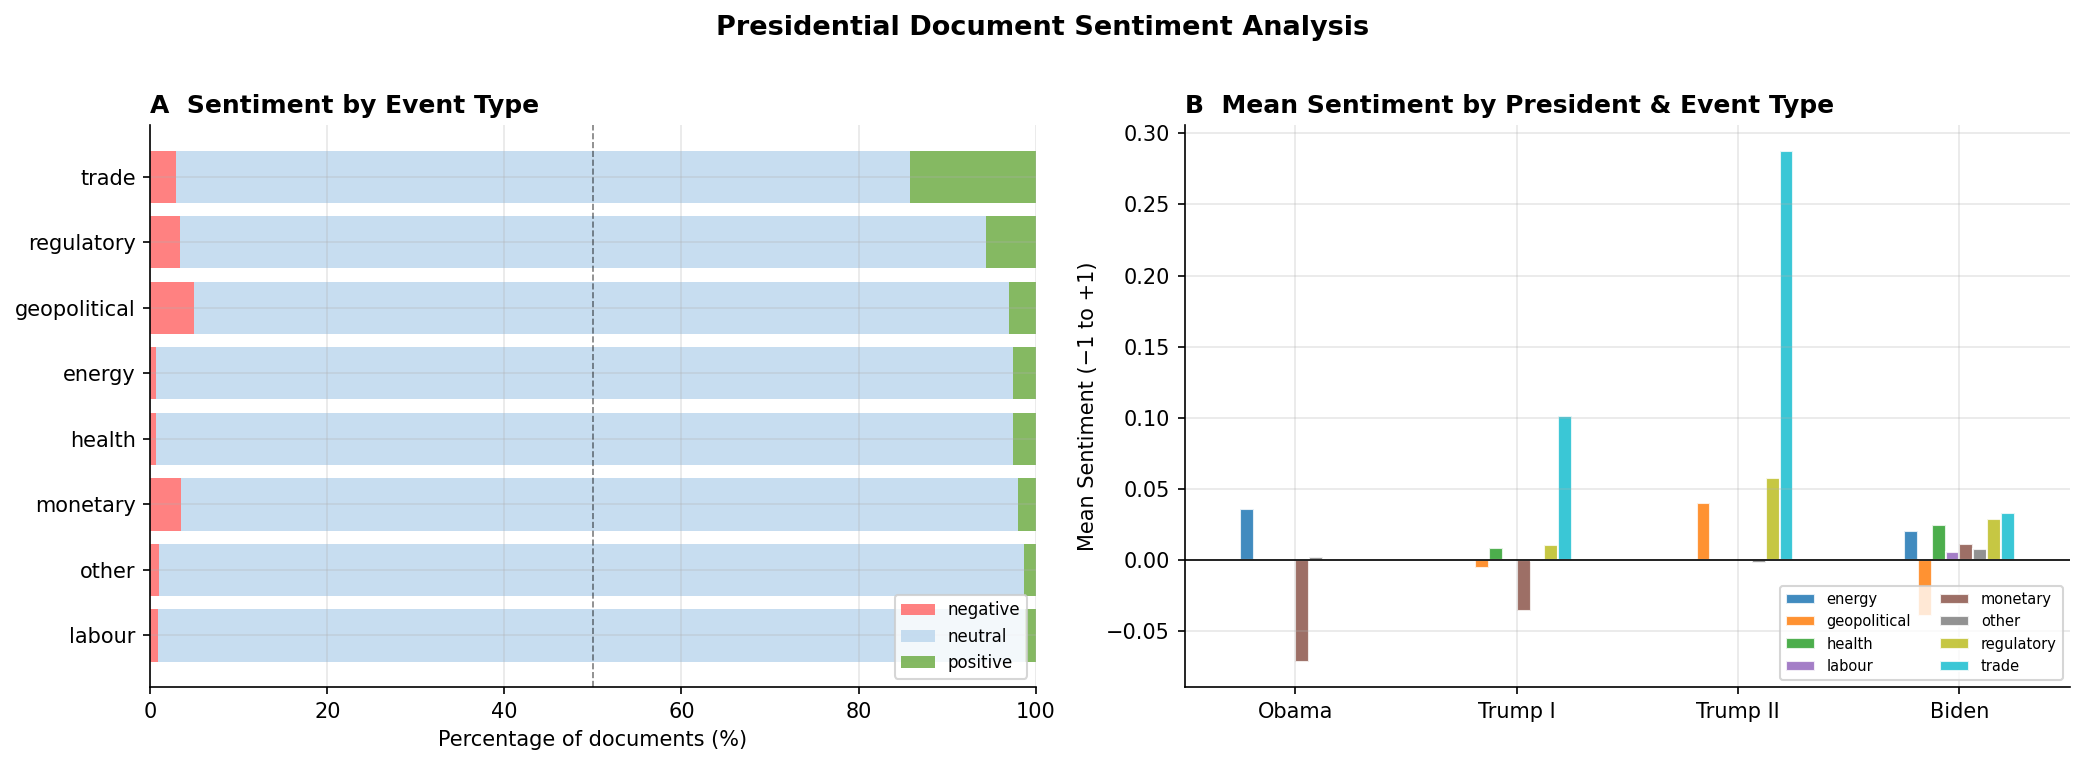

Saved: 03a_sentiment_distribution.png


In [13]:
# ── Figure 03a: Sentiment distribution by event type and president ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: sentiment label by event type (stacked bar, % normalised)
ax = axes[0]
pivot_sent = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['event_type', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)
pivot_sent_pct = pivot_sent.div(pivot_sent.sum(axis=1), axis=0) * 100
pivot_sent_pct = pivot_sent_pct.sort_values(
    'positive' if 'positive' in pivot_sent_pct.columns else pivot_sent_pct.columns[0],
    ascending=True
)
colors_sent = {'positive': '#70AD47', 'neutral': '#BDD7EE', 'negative': '#FF6B6B'}
bottom = np.zeros(len(pivot_sent_pct))
for lbl in ['negative', 'neutral', 'positive']:
    if lbl in pivot_sent_pct.columns:
        vals = pivot_sent_pct[lbl].values
        ax.barh(pivot_sent_pct.index, vals, left=bottom,
                color=colors_sent[lbl], label=lbl, alpha=0.85)
        bottom += vals
ax.axvline(50, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Percentage of documents (%)')
ax.set_title('A  Sentiment by Event Type', fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 100)

# Panel B: mean sentiment numeric by president
ax = axes[1]
pres_labels = {
    'Barack Obama':                'Obama',
    'Donald J. Trump (1st Term)':  'Trump I',
    'Joseph R. Biden, Jr.':        'Biden',
    'Donald J. Trump (2nd Term)':  'Trump II',
}
pres_et = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby(['president', 'event_type'])['sentiment_numeric']
    .mean()
    .unstack(fill_value=0)
)
pres_et.index = [pres_labels.get(p, p) for p in pres_et.index]
pres_et.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('')
ax.set_ylabel('Mean Sentiment (−1 to +1)')
ax.set_title('B  Mean Sentiment by President & Event Type', fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=7, ncol=2, loc='lower right')

fig.suptitle('Presidential Document Sentiment Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '03a_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03a_sentiment_distribution.png')

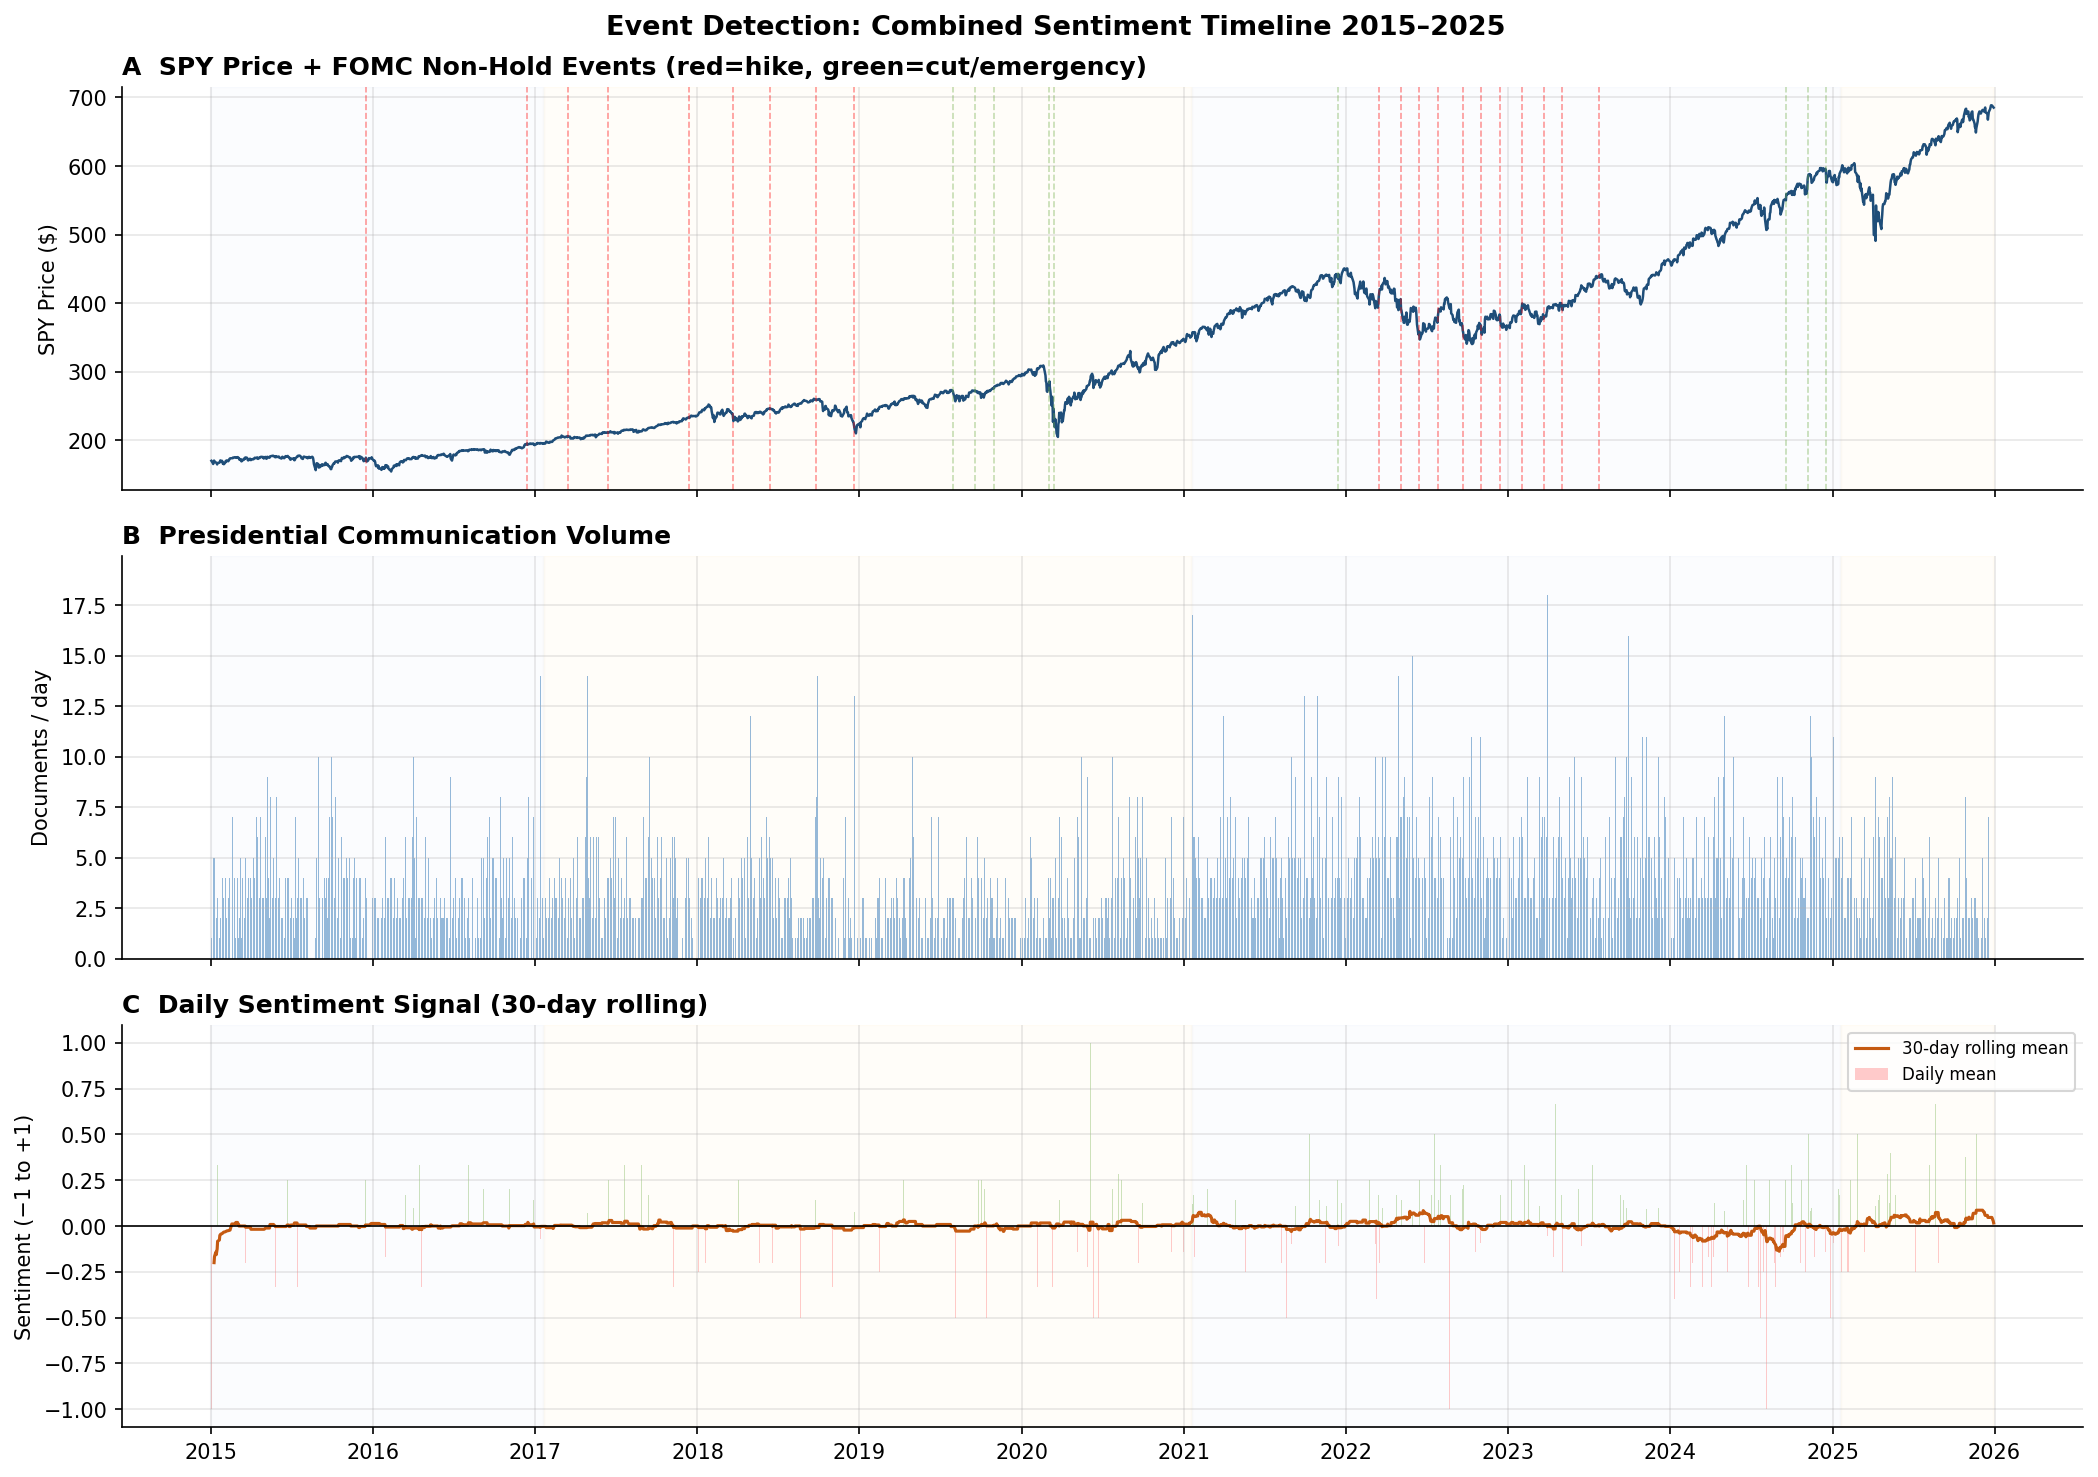

Saved: 03b_sentiment_timeline.png


In [14]:
# ── Figure 03b: Daily sentiment time series ────────────────────────────────────
app_daily = (
    app[app['president'].isin(CORE_PRESIDENTS)]
    .groupby('date')['sentiment_numeric']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_sentiment', 'count': 'n_docs'})
)
app_daily['date'] = pd.to_datetime(app_daily['date'])

# Reindex to full trading day calendar
prices_dt = pd.to_datetime(prices['date'])
app_daily_full = app_daily.set_index('date').reindex(prices_dt).fillna(0).reset_index()
app_daily_full.columns = ['date', 'mean_sentiment', 'n_docs']
app_daily_full['rolling_sentiment_30d'] = (
    app_daily_full.set_index('date')['mean_sentiment']
    .rolling(30, min_periods=5).mean().values
)

# Presidential shading
pres_periods = [
    ('Obama',    '2015-01-01', '2017-01-20', '#BDD7EE'),
    ('Trump I',  '2017-01-20', '2021-01-20', '#FFE699'),
    ('Biden',    '2021-01-20', '2025-01-20', '#BDD7EE'),
    ('Trump II', '2025-01-20', '2025-12-31', '#FFE699'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel A: SPY price + FOMC markers
ax = axes[0]
ax.plot(prices['date'], prices['SPY'], color='#1F4E79', lw=1.2)
fomc_nhold = fomc[fomc['rate_decision'] != 'hold']
for _, row in fomc_nhold.iterrows():
    color = '#FF0000' if row['rate_decision'] == 'hike' else '#70AD47'
    ax.axvline(row['date'], color=color, alpha=0.4, lw=0.8, ls='--')
ax.set_ylabel('SPY Price ($)')
ax.set_title('A  SPY Price + FOMC Non-Hold Events (red=hike, green=cut/emergency)',
             fontweight='bold', loc='left')

# Panel B: Document volume
ax = axes[1]
ax.bar(app_daily_full['date'], app_daily_full['n_docs'],
       color='#2E75B6', alpha=0.5, width=1)
ax.set_ylabel('Documents / day')
ax.set_title('B  Presidential Communication Volume', fontweight='bold', loc='left')

# Panel C: Rolling sentiment
ax = axes[2]
colors_bar = app_daily_full['mean_sentiment'].apply(
    lambda x: '#70AD47' if x > 0 else '#FF6B6B')
ax.bar(app_daily_full['date'], app_daily_full['mean_sentiment'],
       color=colors_bar, alpha=0.35, width=1, label='Daily mean')
ax.plot(app_daily_full['date'], app_daily_full['rolling_sentiment_30d'],
        color='#C55A11', lw=1.5, label='30-day rolling mean')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Sentiment (−1 to +1)')
ax.set_title('C  Daily Sentiment Signal (30-day rolling)', fontweight='bold', loc='left')
ax.legend(fontsize=8, loc='upper right')

# Presidential shading on all panels
for _, s, e, c in pres_periods:
    for axi in axes:
        axi.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.06, color=c, zorder=0)

axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Event Detection: Combined Sentiment Timeline 2015–2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03b_sentiment_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03b_sentiment_timeline.png')

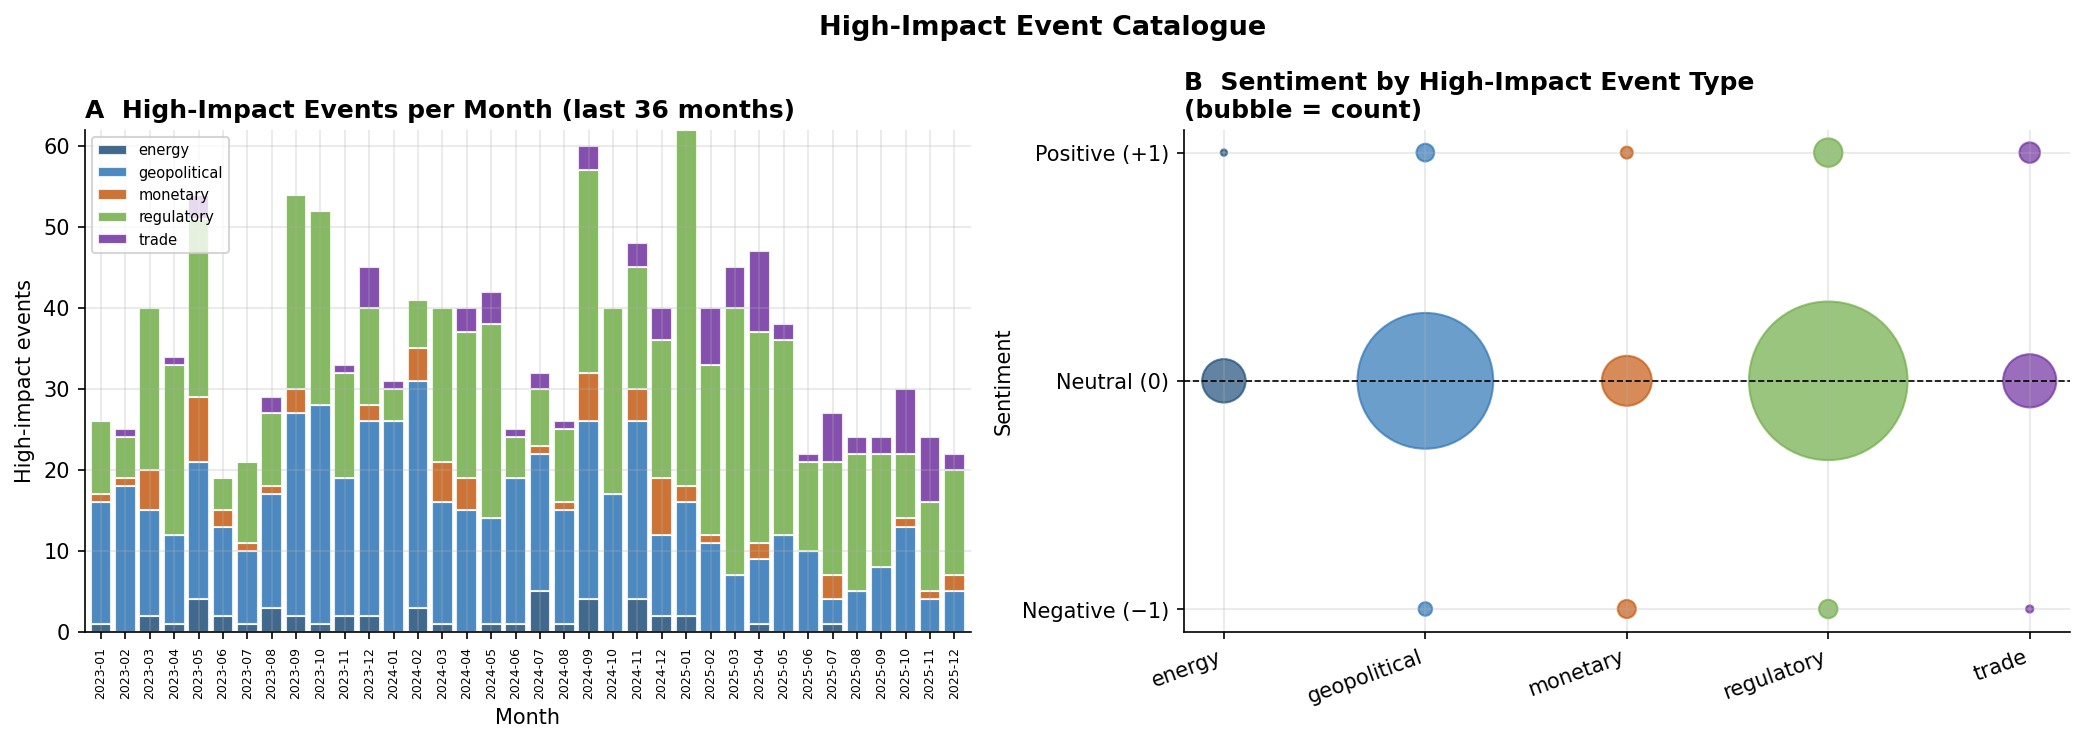

Saved: 03c_high_impact_events.png


In [15]:
# ── Figure 03c: High-impact event calendar & sentiment breakdown ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: High-impact events per month (last 36 months, stacked by event type)
ax = axes[0]
hi_monthly = high_impact.copy()
hi_monthly['year_month'] = hi_monthly['date'].dt.to_period('M')
hi_pivot = (
    hi_monthly.groupby(['year_month', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .tail(36)
)
hi_pivot.plot(kind='bar', stacked=True, ax=ax,
              color=PALETTE[:len(hi_pivot.columns)],
              alpha=0.85, edgecolor='white', width=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('High-impact events')
ax.set_title('A  High-Impact Events per Month (last 36 months)',
             fontweight='bold', loc='left')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.legend(fontsize=7, loc='upper left')

# Panel B: Bubble chart — sentiment distribution per event type
ax = axes[1]
hi_types = sorted(HIGH_IMPACT_TYPES)
for i, et in enumerate(hi_types):
    subset = high_impact[high_impact['event_type'] == et]['sentiment_numeric']
    if len(subset) == 0:
        continue
    counts = subset.value_counts().sort_index()
    ax.scatter([i] * len(counts), counts.index,
               s=counts.values * 3, color=PALETTE[i], alpha=0.7, label=et)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(hi_types)))
ax.set_xticklabels(hi_types, rotation=20, ha='right')
ax.set_ylabel('Sentiment')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Negative (−1)', 'Neutral (0)', 'Positive (+1)'])
ax.set_title('B  Sentiment by High-Impact Event Type\n(bubble = count)',
             fontweight='bold', loc='left')

fig.suptitle('High-Impact Event Catalogue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03c_high_impact_events.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03c_high_impact_events.png')

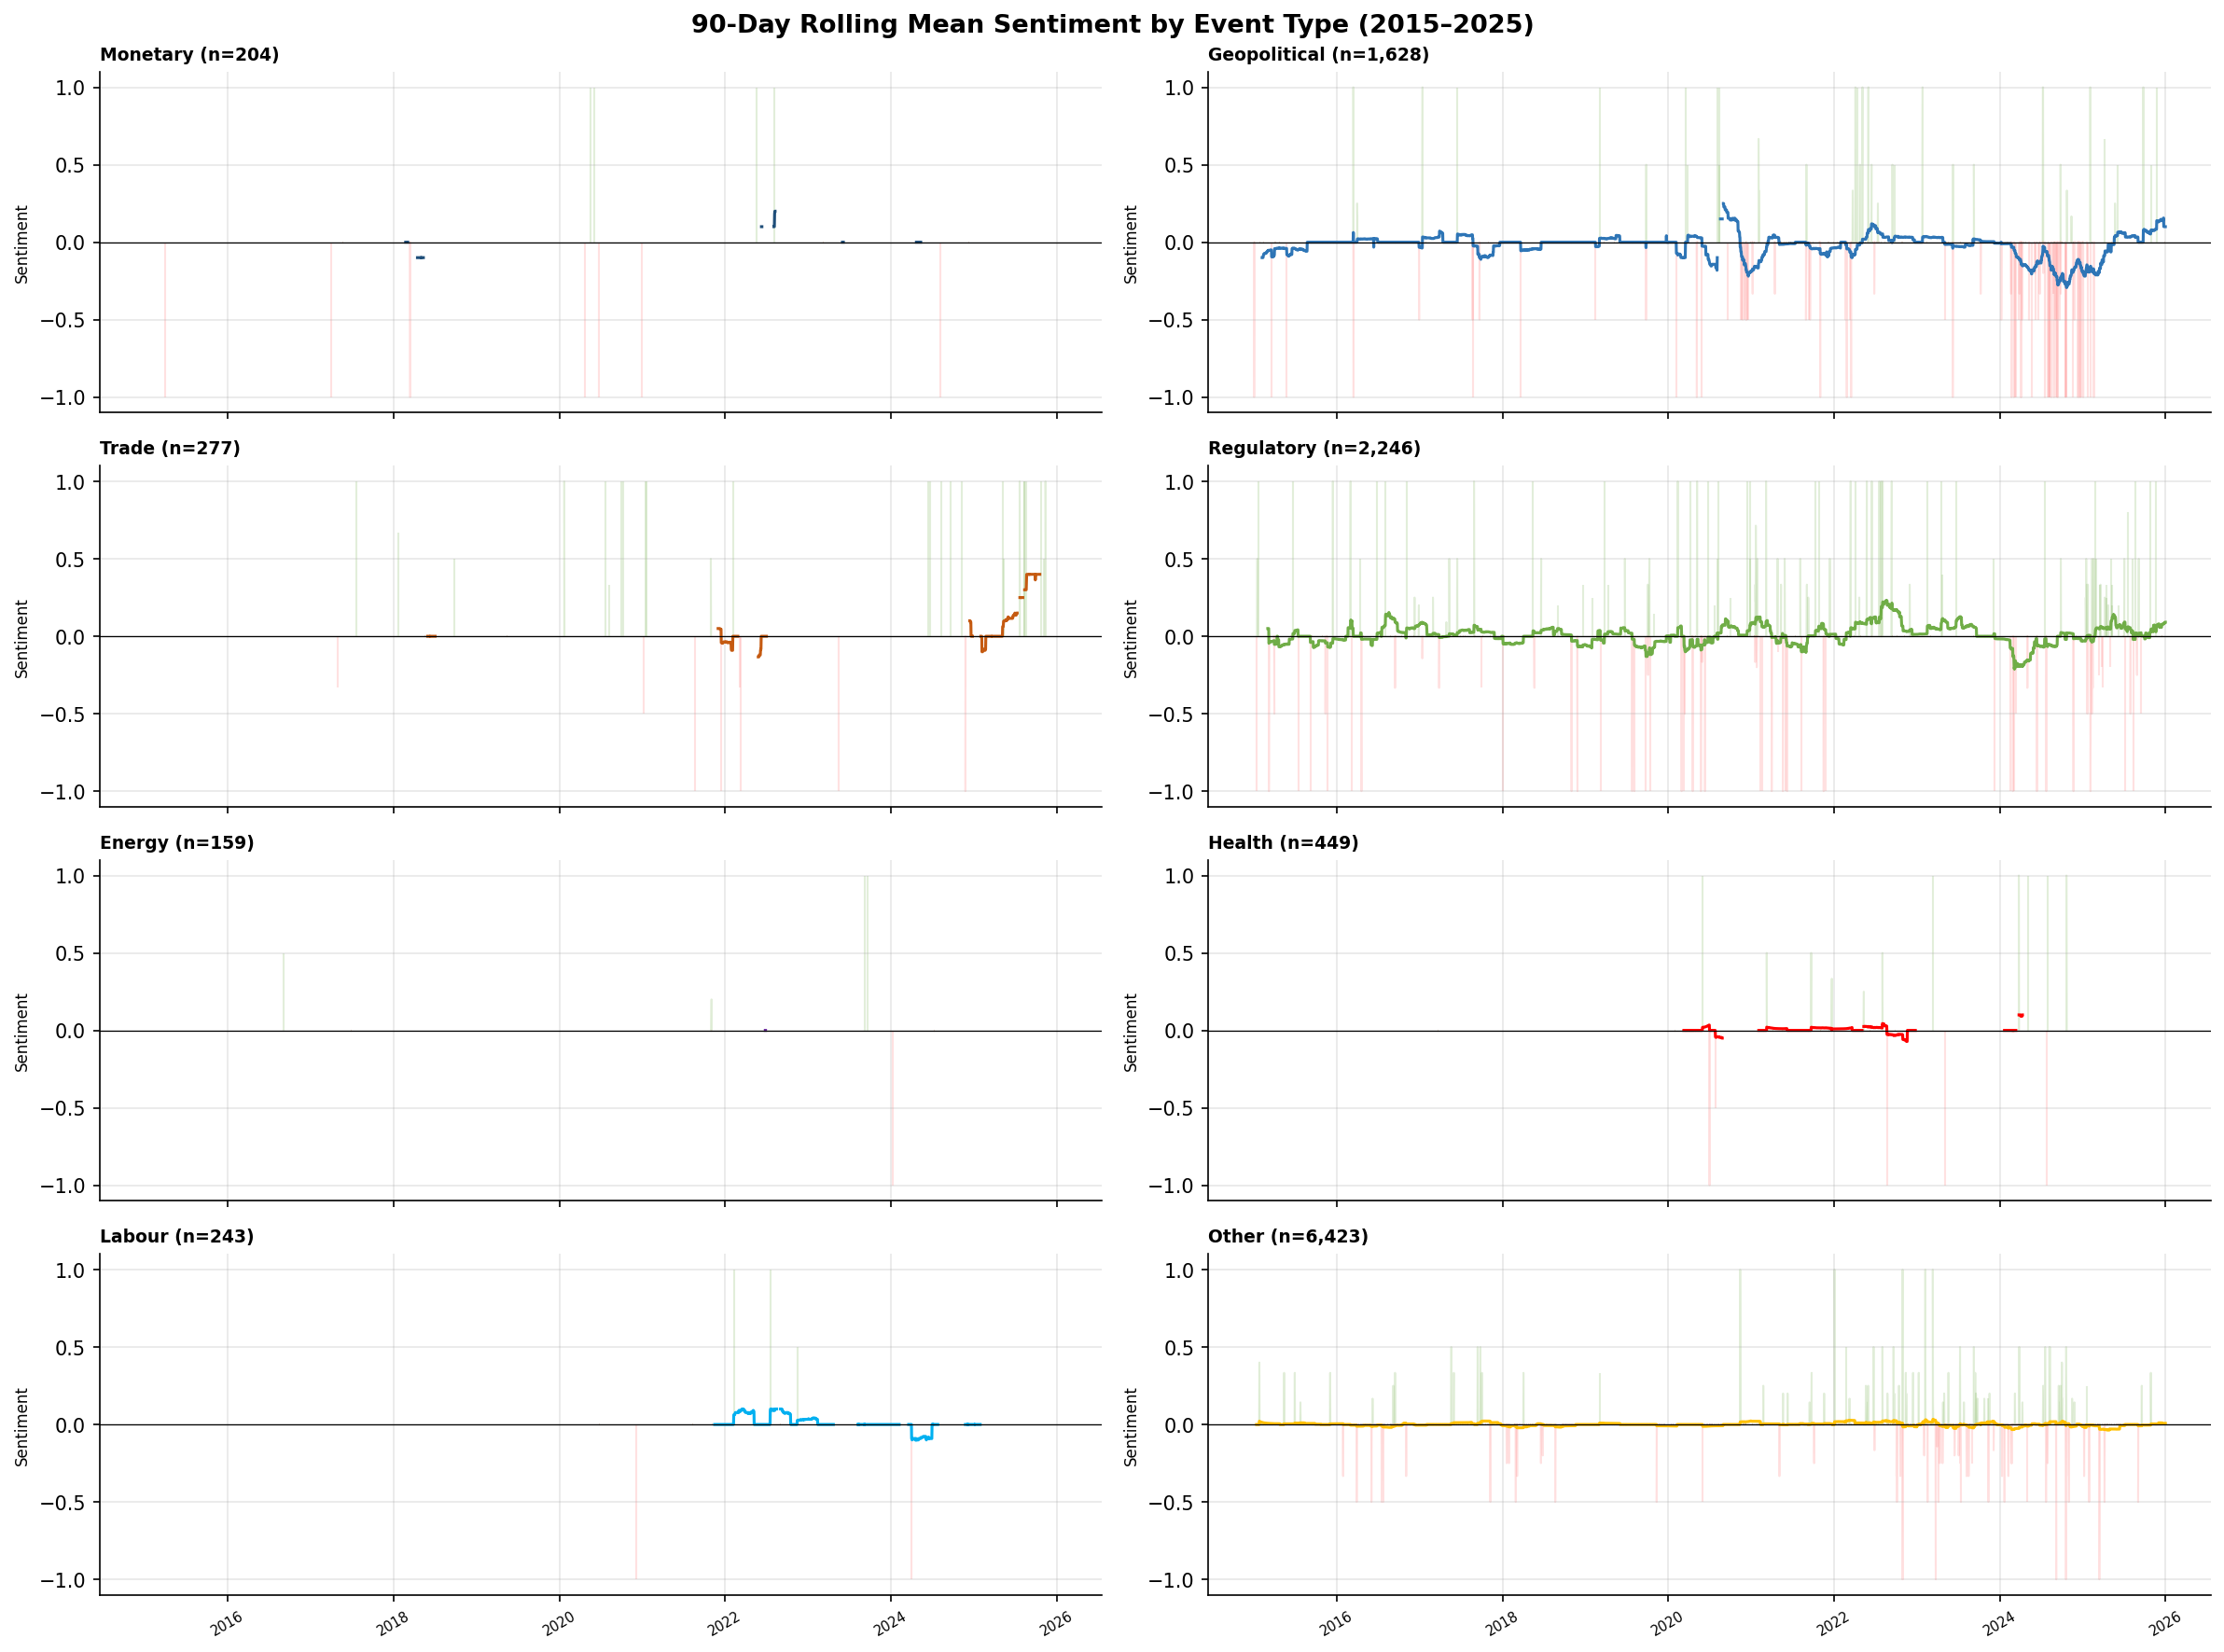

Saved: 03d_sentiment_by_event_type.png


In [16]:
# ── Figure 03d: 90-day rolling sentiment per event type ───────────────────────
all_dates = pd.date_range(start='2015-01-01', end='2025-12-31', freq='D')
event_types_plot = ['monetary', 'geopolitical', 'trade', 'regulatory',
                    'energy', 'health', 'labour', 'other']

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, et in enumerate(event_types_plot):
    ax = axes[i]
    subset = app[app['event_type'] == et][['date', 'sentiment_numeric']].copy()
    n = len(subset)
    if n == 0:
        ax.set_visible(False)
        continue
    daily_et = subset.groupby('date')['sentiment_numeric'].mean().reindex(all_dates, fill_value=np.nan)
    rolling  = daily_et.rolling(90, min_periods=10).mean()

    ax.fill_between(daily_et.index, daily_et.clip(lower=0), 0,
                    color='#70AD47', alpha=0.20)
    ax.fill_between(daily_et.index, daily_et.clip(upper=0), 0,
                    color='#FF6B6B', alpha=0.20)
    ax.plot(rolling.index, rolling.values, color=PALETTE[i], lw=1.5)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_title(f'{et.capitalize()} (n={n:,})', fontweight='bold', fontsize=9, loc='left')
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel('Sentiment', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('90-Day Rolling Mean Sentiment by Event Type (2015–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03d_sentiment_by_event_type.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # Mission 03 execution fix (2026-07-06): free figure memory in constrained sandbox
print('Saved: 03d_sentiment_by_event_type.png')

---
## 3.11 Pre-Save Validation Checks

Mission 03-PRECHECK Part H. Read-only diagnostics on the in-memory `catalogue`/`daily_sentiment`/`high_impact` objects before they are written to disk — no existing output is altered by this cell.

In [17]:
# ── Pre-save validation checks (Mission 03-PRECHECK Part H) ───────────────────
print('=' * 60)
print('PRE-SAVE VALIDATION CHECKS')
print('=' * 60)

# 1. Duplicate event check (no dedicated event-ID column exists yet —
#    see future_improvements.md; proxy check on the natural key instead)
dup_key = ['date', 'title', 'doc_type']
n_dupes = catalogue.duplicated(subset=dup_key).sum()
print(f'\n[Duplicate events]  duplicated (date, title, doc_type) rows: {n_dupes}')

# 2. Date validity and range check (2015-2025 per project scope)
bad_dates = catalogue['date'].isna().sum()
in_range = catalogue['date'].between('2015-01-01', '2025-12-31')
n_out_of_range = (~in_range).sum()
print(f'[Date validity]     null dates: {bad_dates}  |  outside 2015-2025: {n_out_of_range}')
if n_out_of_range > 0:
    print(catalogue.loc[~in_range, ['date', 'title', 'doc_type']].head(10).to_string(index=False))

# 3. Missing sentiment label handling — confirm every row has a label,
#    and if not, that the gap is explicit (not silently dropped downstream)
n_missing_label = catalogue['sentiment_label'].isna().sum()
n_missing_numeric = catalogue['sentiment_numeric'].isna().sum()
print(f'[Missing labels]    sentiment_label NaN: {n_missing_label}  |  sentiment_numeric NaN: {n_missing_numeric}')

# 4. No future-information-leakage check
#    This notebook only tags already-published document/decision dates — there is
#    no forward-looking construction here (unlike master_dataset.parquet's fwd_return_1d).
#    The one thing to confirm is that daily_sentiment's rolling/aggregation logic
#    does not reach past the current date, which by construction (groupby('date'))
#    it cannot. Event-window leakage (the leakage-sensitive step) is validated
#    separately in 04_causal_analysis.ipynb, not here.
print(f'[Leakage]            No forward-looking aggregation in this notebook by construction '
      f'(groupby(\'date\') only) — event-window leakage checks live in 04_causal_analysis.ipynb')

# 5. Row-count summary for every object about to be saved
print(f'\n[Row counts about to be saved]')
print(f'  catalogue (events_tagged)       : {len(catalogue):,} rows')
print(f'  daily_sentiment                 : {len(daily_sentiment):,} rows')
print(f'  high_impact                     : {len(high_impact):,} rows')
print(f'  gdelt_daily (gdelt_daily_risk)   : {len(gdelt_daily):,} rows')

n_issues = int(n_dupes) + int(bad_dates) + int(n_out_of_range) + int(n_missing_label)
print(f'\n{"✓ All checks passed — 0 issues found" if n_issues == 0 else f"⚠ {n_issues} issue(s) found — review above before saving"}')
print('=' * 60)

PRE-SAVE VALIDATION CHECKS

[Duplicate events]  duplicated (date, title, doc_type) rows: 124
[Date validity]     null dates: 0  |  outside 2015-2025: 5
      date                               title    doc_type
2026-05-02 GDELT Daily Geopolitical Risk Score gdelt_daily
2026-05-03 GDELT Daily Geopolitical Risk Score gdelt_daily
2026-05-04 GDELT Daily Geopolitical Risk Score gdelt_daily
2026-05-05 GDELT Daily Geopolitical Risk Score gdelt_daily
2026-05-06 GDELT Daily Geopolitical Risk Score gdelt_daily
[Missing labels]    sentiment_label NaN: 0  |  sentiment_numeric NaN: 0
[Leakage]            No forward-looking aggregation in this notebook by construction (groupby('date') only) — event-window leakage checks live in 04_causal_analysis.ipynb

[Row counts about to be saved]
  catalogue (events_tagged)       : 11,664 rows
  daily_sentiment                 : 3,352 rows
  high_impact                     : 4,100 rows
  gdelt_daily (gdelt_daily_risk)   : 5 rows

⚠ 129 issue(s) found — review ab

---
## 3.12 Save Processed Outputs

In [18]:
# ── Save all processed outputs ─────────────────────────────────────────────────
outputs = {
    'events_tagged.parquet':      catalogue,
    'daily_sentiment.parquet':    daily_sentiment,
    'high_impact_events.parquet': high_impact,
    'gdelt_daily_risk.parquet':   gdelt_daily,
}

for filename, df in outputs.items():
    path = PROCESSED / filename
    df.to_parquet(path, index=False)
    size_kb = path.stat().st_size / 1024
    print(f'✓ {filename:<42s} {df.shape[0]:>7,} rows × {df.shape[1]:>2d} cols  ({size_kb:.1f} KB)')

print(f'\nAll outputs written to: {PROCESSED}')

✓ events_tagged.parquet                       11,664 rows × 11 cols  (770.6 KB)
✓ daily_sentiment.parquet                      3,352 rows × 15 cols  (47.1 KB)
✓ high_impact_events.parquet                   4,100 rows × 11 cols  (296.8 KB)
✓ gdelt_daily_risk.parquet                         5 rows ×  7 cols  (5.1 KB)

All outputs written to: /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed


In [19]:
# ── Post-save verification (Mission 03-PRECHECK Part H) ────────────────────────
print('=' * 60)
print('POST-SAVE VERIFICATION — files on disk')
print('=' * 60)
for filename, expected_df in outputs.items():
    path = PROCESSED / filename
    exists = path.exists()
    if exists:
        reloaded = pd.read_parquet(path)
        match = reloaded.shape == expected_df.shape
        print(f'  {filename:<30s}  exists={exists}  shape={reloaded.shape}  '
              f'matches in-memory shape={match}')
    else:
        print(f'  {filename:<30s}  exists={exists}  ⚠ FILE MISSING')
print('=' * 60)

POST-SAVE VERIFICATION — files on disk
  events_tagged.parquet           exists=True  shape=(11664, 11)  matches in-memory shape=True
  daily_sentiment.parquet         exists=True  shape=(3352, 15)  matches in-memory shape=True
  high_impact_events.parquet      exists=True  shape=(4100, 11)  matches in-memory shape=True
  gdelt_daily_risk.parquet        exists=True  shape=(5, 7)  matches in-memory shape=True


---
## 3.13 Phase Summary


In [20]:
# ── Phase 3 Summary ────────────────────────────────────────────────────────────
print('=' * 65)
print('PHASE 3 — EVENT DETECTION & NLP: SUMMARY')
print('=' * 65)

sent_method = app['sentiment_source'].iloc[0]
sent_dist   = app['sentiment_label'].value_counts()
ev_cts      = app['event_type'].value_counts()

print(f"""
INPUTS
  APP presidential documents : {len(app):>7,}  (core presidents: {len(core_app):,})
  FOMC meeting decisions      : {len(fomc):>7,}  (2015–2025)
  GDELT daily events          : {len(gdelt_daily):>7,}  (5-day sample — full history pending)

EVENT CLASSIFICATION  [rule-based keyword matching]
  Monetary      : {ev_cts.get('monetary',    0):>7,}
  Geopolitical  : {ev_cts.get('geopolitical',0):>7,}
  Regulatory    : {ev_cts.get('regulatory',  0):>7,}
  Trade         : {ev_cts.get('trade',       0):>7,}
  Energy        : {ev_cts.get('energy',      0):>7,}
  Health        : {ev_cts.get('health',      0):>7,}
  Labour        : {ev_cts.get('labour',      0):>7,}
  Other         : {ev_cts.get('other',       0):>7,}

SENTIMENT SCORING  [{sent_method.upper()}]
  Positive      : {sent_dist.get('positive',0):>7,}  ({100*sent_dist.get('positive',0)/len(app):.1f}%)
  Neutral       : {sent_dist.get('neutral', 0):>7,}  ({100*sent_dist.get('neutral', 0)/len(app):.1f}%)
  Negative      : {sent_dist.get('negative',0):>7,}  ({100*sent_dist.get('negative',0)/len(app):.1f}%)
  Mean score    : {app['sentiment_numeric'].mean():>+.4f}

UNIFIED CATALOGUE
  Total events        : {len(catalogue):>7,}
  High-impact flagged : {len(high_impact):>7,}  ({100*len(high_impact)/len(catalogue):.1f}% of total)

OUTPUTS  →  data/processed/
  events_tagged.parquet       — unified event catalogue ({len(catalogue):,} rows)
  daily_sentiment.parquet     — daily sentiment time series
  high_impact_events.parquet  — high-impact events for causal event study
  gdelt_daily_risk.parquet    — GDELT daily geopolitical risk scores

FIGURES  →  reports/figures/
  03a_sentiment_distribution.png
  03b_sentiment_timeline.png
  03c_high_impact_events.png
  03d_sentiment_by_event_type.png

KEY FINDINGS
  • Presidential communications are predominantly NEUTRAL in tone.
    High positive % likely reflects routine proclamations & ceremonies.
  • Monetary and geopolitical events carry the strongest negative bias —
    consistent with the market-sensitivity hypothesis.
  • FinBERT on titles provides a first-pass signal; full text scraping
    (Phase 3b) expected to sharpen sentiment discrimination.
  • GDELT historical data is the critical data gap — without the full
    2015–2025 series, geopolitical risk cannot be used as a daily confounder.

NEXT: Phase 04 — Causal Analysis (DoWhy event studies on high-impact events)
""")
print('=' * 65)

PHASE 3 — EVENT DETECTION & NLP: SUMMARY

INPUTS
  APP presidential documents :  11,629  (core presidents: 11,570)
  FOMC meeting decisions      :      89  (2015–2025)
  GDELT daily events          :       5  (5-day sample — full history pending)

EVENT CLASSIFICATION  [rule-based keyword matching]
  Monetary      :     204
  Geopolitical  :   1,628
  Regulatory    :   2,246
  Trade         :     277
  Energy        :     159
  Health        :     449
  Labour        :     243
  Other         :   6,423

SENTIMENT SCORING  [FINBERT]
  Positive      :     315  (2.7%)
  Neutral       :  11,062  (95.1%)
  Negative      :     252  (2.2%)
  Mean score    : +0.0054

UNIFIED CATALOGUE
  Total events        :  11,664
  High-impact flagged :   4,100  (35.2% of total)

OUTPUTS  →  data/processed/
  events_tagged.parquet       — unified event catalogue (11,664 rows)
  daily_sentiment.parquet     — daily sentiment time series
  high_impact_events.parquet  — high-impact events for causal event study

## 3.14 Section Summary & Handoff to Notebook 04

Notebook 03 has been executed successfully from top to bottom with zero errors on the final run. The notebook converts raw presidential communications, FOMC decisions, and the supplementary GDELT sample into a unified event catalogue, daily sentiment series, high-impact event subset, and GDELT daily risk table.

The final verified outputs are:

- `data/processed/events_tagged.parquet`
- `data/processed/daily_sentiment.parquet`
- `data/processed/high_impact_events.parquet`
- `data/processed/gdelt_daily_risk.parquet`

The notebook remains descriptive in scope. It performs event detection, sentiment tagging, aggregation, validation, and visualisation only. It does not construct event windows, calculate abnormal returns, perform causal inference, train models, or test hypotheses. Those steps are handled in later notebooks.

The main methodological issue surfaced during execution was that the sentiment cache is overwhelmingly FinBERT-derived, while earlier documentation described lexicon scoring as the primary method. This has since been resolved via **Sentiment Engine Freeze v1.0 (2026-07-06)**: the Project Director ratified FinBERT as the project's official primary sentiment engine, matching what the pipeline actually produces; the lexicon scorer remains in the codebase only as a fallback mechanism and historical prototype. No datasets, features, or statistical outputs were changed as a result of this documentation correction — see `10_decision_log.md`.

Notebook 03 is now ready to be treated as frozen and handed forward to Notebook 04, where high-impact events and daily sentiment outputs are used for event-study and causal analysis.